In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Linear Regression

In [2]:
df = pd.read_csv("data/FINAL_DF.csv")

In [86]:
df.head()

,Geography,LocYear,% >= HS,% >= Bachelor's,"Pov for 25yo<=, <HS","Pov for 25<=, >=Bachelor's",GeoFIPS,HFR,SNAP_rate,DPI_rate,PI_rate
0,0400000US01,AL2010,0.821,0.219,0.300,0.041,1000,0.456,0.147621,0.082011,0.089287
1,0400000US02,AK2010,0.910,0.279,0.177,0.028,2000,0.611,0.132925,0.128447,0.138935
2,0400000US04,AZ2010,0.856,0.259,0.301,0.046,4000,0.346,0.139955,0.085180,0.092639
3,0400000US05,AR2010,0.829,0.195,0.267,0.039,5000,0.493,0.142676,0.077484,0.084426
4,0400000US06,CA2010,0.807,0.301,0.253,0.049,6000,0.174,0.087893,0.115410,0.129771


In [87]:
X = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "DPI_rate", "PI_rate"]] 

In [88]:
y = df["HFR"]

In [89]:
model = LinearRegression()

In [90]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [102]:
r_sq = model.score(X, y)
print(f"coefficient of determination: {r_sq}")

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_)
}).sort_values(by='Importance', ascending=False)

print(importance_df)

coefficient of determination: 0.6115496285526327
               Feature  Importance
4             DPI_rate   12.027910
5              PI_rate   11.234479
0              % >= HS    2.340249
1      % >= Bachelor's    1.555581
2  Pov for 25yo<=, <HS    1.013790
3            SNAP_rate    0.779303


Now without DPI_rate

In [116]:
X = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "PI_rate"]] 
y = df["HFR"]
model = LinearRegression()
model.fit(X, y)

r_sq = model.score(X, y)
print(f"coefficient of determination: {r_sq}")

importance_df2 = pd.DataFrame({
    'Feature': X.columns,
    'LinearReg': abs(model.coef_)
}).sort_values(by='LinearReg', ascending=False)

importance_df2

coefficient of determination: 0.5919085723335016


,Feature,LinearReg
0,% >= HS,2.402364
1,% >= Bachelor's,1.880572
4,PI_rate,1.279294
3,SNAP_rate,0.866187
2,"Pov for 25yo<=, <HS",0.814288


# Single Linear Regression

In [24]:
def r2_scores(X, y):
    r2_dict = dict()
    for col_name in X:
        X2 = X[[col_name]]
        model = LinearRegression()
        model.fit(X2, y)
        r_sq = model.score(X2, y)
        r2_dict[col_name] = r_sq
        r_sq = None
    return r2_dict

In [27]:
single_scores = r2_scores(X, y)

In [107]:
single_scores

{'% >= HS': 0.009766193382809818,
 "% >= Bachelor's": 0.3491291089083367,
 'Pov for 25yo<=, <HS': 0.040661220695324074,
 'SNAP_rate': 0.005490702335183673,
 'DPI_rate': 0.2618667749529803,
 'PI_rate': 0.3068977174271347}

In [117]:
single_lr = pd.DataFrame(list(single_scores.items()), columns=['Feature', 'SingleLinearReg'])
single_lr

,Feature,SingleLinearReg
0,% >= HS,0.009766
1,% >= Bachelor's,0.349129
2,"Pov for 25yo<=, <HS",0.040661
3,SNAP_rate,0.005491
4,DPI_rate,0.261867
5,PI_rate,0.306898


In [32]:
import matplotlib.pyplot as plt

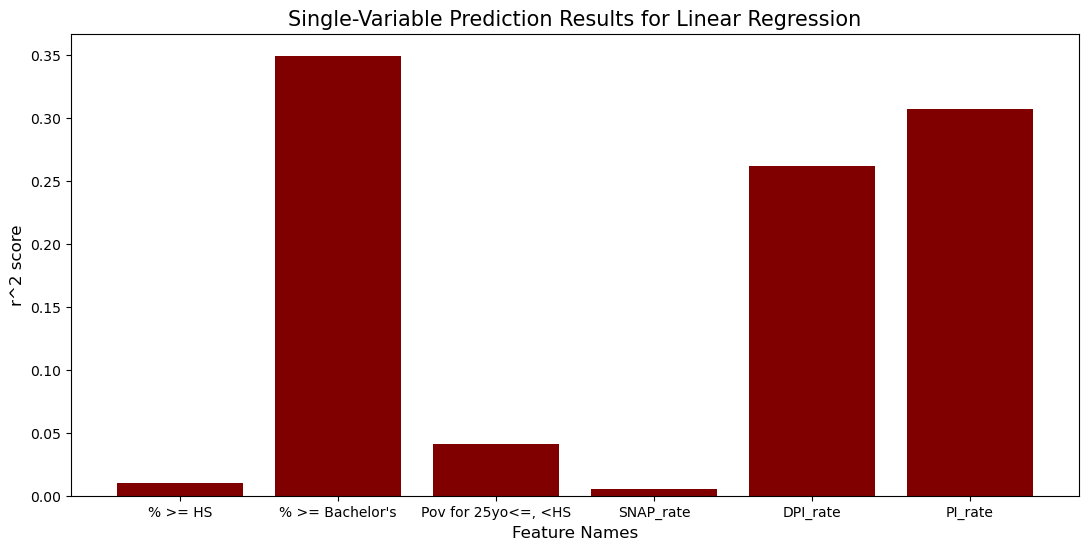

In [69]:
plt.figure(figsize=(13, 6))
plt.bar(single_scores.keys(), single_scores.values(), color="maroon")
plt.xlabel("Feature Names", fontsize=12)
plt.ylabel("r^2 score", fontsize=12)
plt.xticks(fontsize=10)
plt.title("Single-Variable Prediction Results for Linear Regression", fontsize=15)
plt.show()

# Permutation Feature Importance

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

In [70]:
X = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "DPI_rate", "PI_rate"]] 
y = df["HFR"]

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)

rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
print(f"Model Score: {rf.score(X_test, y_test)}")

r = permutation_importance(rf, X_test, y_test,
                           n_repeats=30,
                           random_state=0, scoring='r2')

column_names_list = X.columns.tolist()

for i in r.importances_mean.argsort()[::-1]:
    print(f"{column_names_list[i]:<8}" + ': '
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}")
    
feature_importance_df = pd.DataFrame({'Feature': column_names_list, 'Permutation': r.importances_mean})    
print("Feature importance:\n", feature_importance_df)
feature_importance_df

Model Score: 0.5974127798037477
% >= Bachelor's: 1.106 +/- 0.174
% >= HS : 0.450 +/- 0.095
PI_rate : 0.370 +/- 0.067
SNAP_rate: 0.023 +/- 0.013
Pov for 25yo<=, <HS: 0.022 +/- 0.017
Feature importance:
                Feature  Permutation
0              % >= HS     0.450088
1      % >= Bachelor's     1.105856
2  Pov for 25yo<=, <HS     0.022015
3            SNAP_rate     0.022964
4              PI_rate     0.370231


,Feature,Permutation
0,% >= HS,0.450088
1,% >= Bachelor's,1.105856
2,"Pov for 25yo<=, <HS",0.022015
3,SNAP_rate,0.022964
4,PI_rate,0.370231


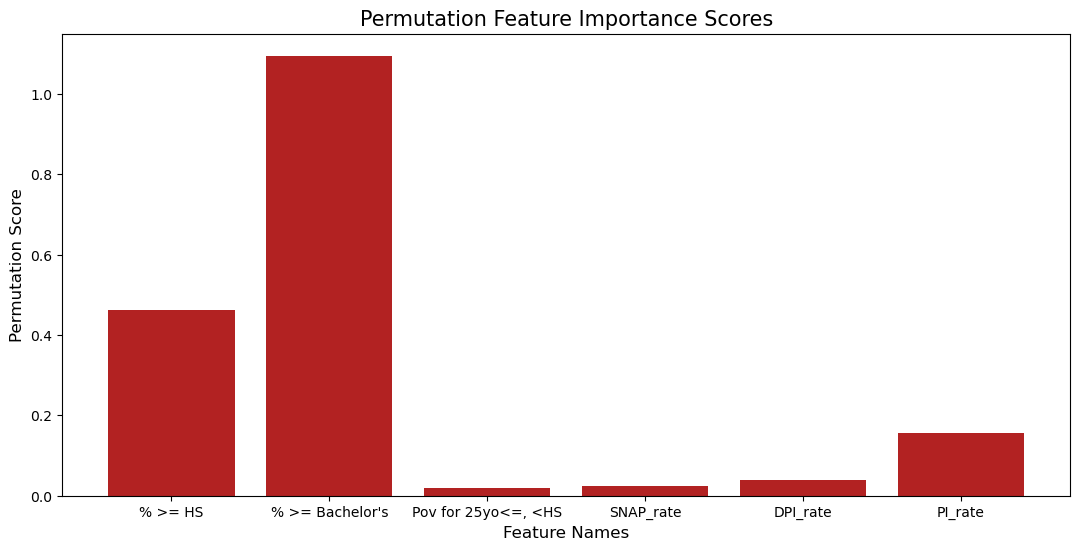

In [79]:
plt.figure(figsize=(13, 6))
plt.bar(feature_importance_df["Feature"], feature_importance_df["Permutation"], color="firebrick")
plt.xlabel("Feature Names", fontsize=12)
plt.ylabel("Permutation Score", fontsize=12)
plt.xticks(fontsize=10)
plt.title("Permutation Feature Importance Scores", fontsize=15)
plt.show()

Running it again with no DPI_rate

In [83]:
X = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "PI_rate"]] 
y = df["HFR"]

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)

rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
print(f"Model Score: {rf.score(X_test, y_test)}")

r = permutation_importance(rf, X_test, y_test,
                           n_repeats=30,
                           random_state=0, scoring='r2')

column_names_list = X.columns.tolist()

for i in r.importances_mean.argsort()[::-1]:
    print(f"{column_names_list[i]:<8}" + ': '
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}")
    
feature_importance_df = pd.DataFrame({'Feature': column_names_list, 'Permutation': r.importances_mean})    
print("Feature importance:\n", feature_importance_df)
feature_importance_df

Model Score: 0.5974127798037477
% >= Bachelor's: 1.106 +/- 0.174
% >= HS : 0.450 +/- 0.095
PI_rate : 0.370 +/- 0.067
SNAP_rate: 0.023 +/- 0.013
Pov for 25yo<=, <HS: 0.022 +/- 0.017
Feature importance:
                Feature  Permutation
0              % >= HS     0.450088
1      % >= Bachelor's     1.105856
2  Pov for 25yo<=, <HS     0.022015
3            SNAP_rate     0.022964
4              PI_rate     0.370231


,Feature,Permutation
0,% >= HS,0.450088
1,% >= Bachelor's,1.105856
2,"Pov for 25yo<=, <HS",0.022015
3,SNAP_rate,0.022964
4,PI_rate,0.370231


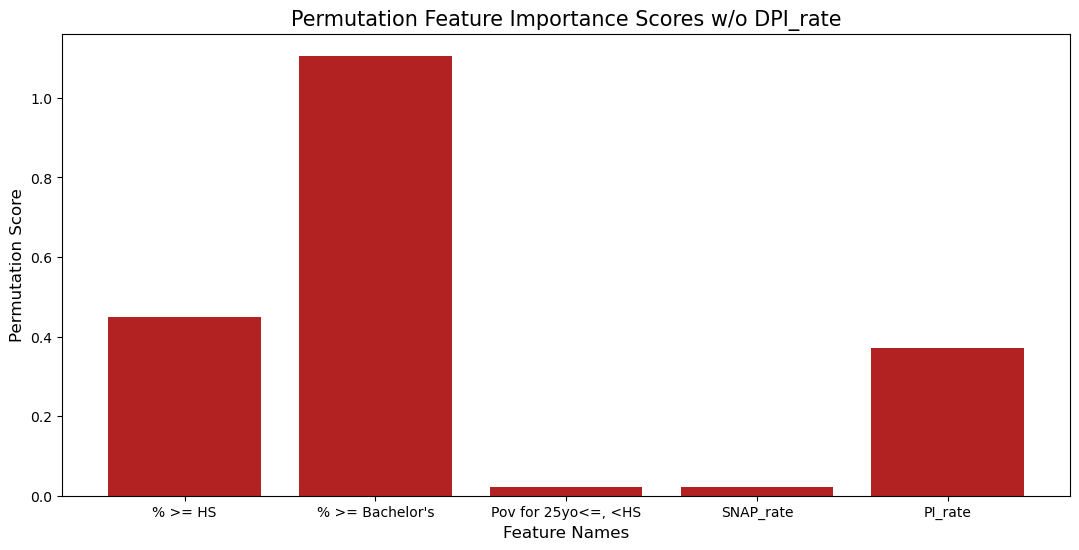

In [85]:
plt.figure(figsize=(13, 6))
plt.bar(feature_importance_df["Feature"], feature_importance_df["Permutation"], color="firebrick")
plt.xlabel("Feature Names", fontsize=12)
plt.ylabel("Permutation Score", fontsize=12)
plt.xticks(fontsize=10)
plt.title("Permutation Feature Importance Scores w/o DPI_rate", fontsize=15)
plt.show()

# Random Forest :)

In [104]:
from sklearn.ensemble import RandomForestRegressor

In [105]:
X = df[["% >= HS", "% >= Bachelor's", "Pov for 25yo<=, <HS", 
                    "SNAP_rate", "PI_rate"]] 
y = df["HFR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)

In [130]:
rf = RandomForestRegressor(bootstrap=False, max_depth=10, max_features=0.7,
                      min_samples_leaf=10,
                      min_samples_split=20,
                      n_estimators=np.int64(1136))
rf.fit(X_train, y_train)

# scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
# print(f"Mean r^2 score accross 5 folds for {rf}: {np.mean(scores):.3f}")
# print(f"All fold scores for {rf}: {scores}\n")

rf.fit(X_train, y_train)
print(rf.score(X_test, y_test))

importance = rf.feature_importances_
D = dict()
for i, v in enumerate(importance):
    D[column_names_list[i]] = v
    print(f'{column_names_list[i]}, Score: {v:.5f}')

0.6199939001637635
% >= HS, Score: 0.18819
% >= Bachelor's, Score: 0.43806
Pov for 25yo<=, <HS, Score: 0.02285
SNAP_rate, Score: 0.03369
PI_rate, Score: 0.31722


{'% >= HS': np.float64(0.1881852741705285),
 "% >= Bachelor's": np.float64(0.4380611890101107),
 'Pov for 25yo<=, <HS': np.float64(0.022845310456682748),
 'SNAP_rate': np.float64(0.03368763188903407),
 'PI_rate': np.float64(0.31722059447364404)}

In [131]:
rf_scores = pd.DataFrame(list(D.items()), columns=['Feature', 'RandomForest'])

In [120]:
importance_df2

,Feature,LinearReg
0,% >= HS,2.402364
1,% >= Bachelor's,1.880572
4,PI_rate,1.279294
3,SNAP_rate,0.866187
2,"Pov for 25yo<=, <HS",0.814288


In [140]:
single_lr = single_lr.drop(4)

In [157]:
single_lr

,Feature,SingleLinearReg
0,% >= HS,0.009766
1,% >= Bachelor's,0.349129
2,"Pov for 25yo<=, <HS",0.040661
3,SNAP_rate,0.005491
5,PI_rate,0.306898


In [158]:
feature_importance_df

,Feature,Permutation
0,% >= HS,0.450088
1,% >= Bachelor's,1.105856
2,"Pov for 25yo<=, <HS",0.022015
3,SNAP_rate,0.022964
4,PI_rate,0.370231


In [159]:
rf_scores

,Feature,RandomForest
0,% >= HS,0.188185
1,% >= Bachelor's,0.438061
2,"Pov for 25yo<=, <HS",0.022845
3,SNAP_rate,0.033688
4,PI_rate,0.317221


In [160]:
df1 = pd.merge(importance_df2, single_lr, on="Feature")
df1

,Feature,LinearReg,SingleLinearReg
0,% >= HS,2.402364,0.009766
1,% >= Bachelor's,1.880572,0.349129
2,PI_rate,1.279294,0.306898
3,SNAP_rate,0.866187,0.005491
4,"Pov for 25yo<=, <HS",0.814288,0.040661


In [161]:
df2 = pd.merge(df1, feature_importance_df, on="Feature")
df2

,Feature,LinearReg,SingleLinearReg,Permutation
0,% >= HS,2.402364,0.009766,0.450088
1,% >= Bachelor's,1.880572,0.349129,1.105856
2,PI_rate,1.279294,0.306898,0.370231
3,SNAP_rate,0.866187,0.005491,0.022964
4,"Pov for 25yo<=, <HS",0.814288,0.040661,0.022015


In [162]:
all_importance_scores = pd.merge(df2, rf_scores, on="Feature")
all_importance_scores

,Feature,LinearReg,SingleLinearReg,Permutation,RandomForest
0,% >= HS,2.402364,0.009766,0.450088,0.188185
1,% >= Bachelor's,1.880572,0.349129,1.105856,0.438061
2,PI_rate,1.279294,0.306898,0.370231,0.317221
3,SNAP_rate,0.866187,0.005491,0.022964,0.033688
4,"Pov for 25yo<=, <HS",0.814288,0.040661,0.022015,0.022845


In [169]:
all_importance_scores

,Feature,LinearReg,SingleLinearReg,Permutation,RandomForest
0,% >= HS,2.402364,0.009766,0.450088,0.188185
1,% >= Bachelor's,1.880572,0.349129,1.105856,0.438061
2,PI_rate,1.279294,0.306898,0.370231,0.317221
3,SNAP_rate,0.866187,0.005491,0.022964,0.033688
4,"Pov for 25yo<=, <HS",0.814288,0.040661,0.022015,0.022845


this is bad :[

In [173]:
from sklearn.preprocessing import MinMaxScaler

good_cols = all_importance_scores[["LinearReg", "SingleLinearReg", "Permutation", "RandomForest"]]
scaler = MinMaxScaler()
scaled_scores = pd.DataFrame(scaler.fit_transform(good_cols), columns=good_cols.columns)
scaled_scores

,LinearReg,SingleLinearReg,Permutation,RandomForest
0,1.000000,0.012442,0.394959,0.398202
1,0.671431,1.000000,1.000000,1.000000
2,0.292811,0.877105,0.321280,0.708969
3,0.032681,0.000000,0.000876,0.026112
4,0.000000,0.102347,0.000000,0.000000


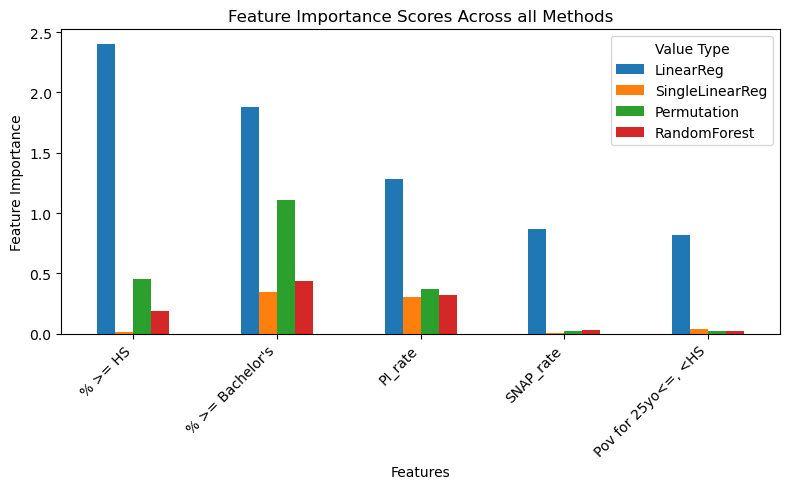

In [180]:
# all_importance_scores = all_importance_scores.set_index('Feature')
all_importance_scores.plot(kind='bar', figsize=(8, 5)) 
plt.title('Feature Importance Scores Across all Methods')
plt.ylabel('Feature Importance')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right') 
plt.legend(title='Value Type')
plt.tight_layout()
plt.show()